# 12.2. 수소 분자 이온

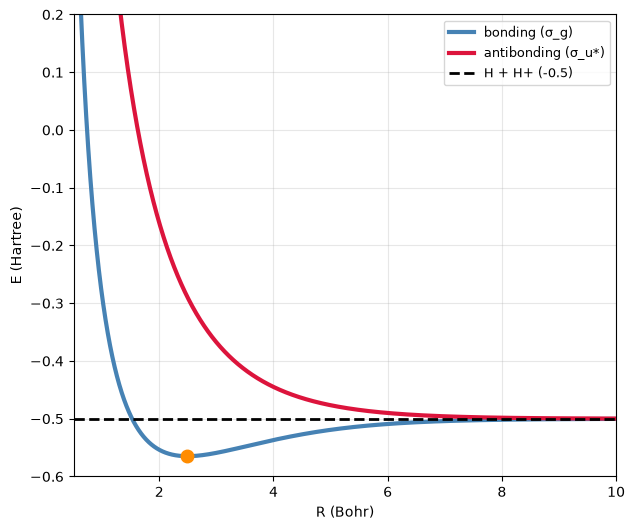

R_e = 2.4935 Bohr = 1.3195 Angstrom
E = -0.564831 Hartree = -15.3698 eV
D_e = 1.7641 eV


In [2]:
import numpy as np
import matplotlib.pyplot as plt


def S(R):
    return np.exp(-R) * (1 + R + R**2 / 3)


def H_AA(R):
    return -0.5 + np.exp(-2 * R) * (1 + 1 / R)


def H_AB(R):
    return -0.5 * S(R) - np.exp(-R) * (1 + R) + S(R) / R


def E_plus(R):
    return (H_AA(R) + H_AB(R)) / (1 + S(R))


def E_minus(R):
    return (H_AA(R) - H_AB(R)) / (1 - S(R))


R = np.linspace(0.5, 10, 5000)
Eg, Eu = E_plus(R), E_minus(R)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(R, Eg, lw=3, color="steelblue", label="bonding (σ_g)")
ax.plot(R, Eu, lw=3, color="crimson", label="antibonding (σ_u*)")
ax.axhline(-0.5, color="black", ls="--", lw=2, label="H + H+ (-0.5)")

i = np.argmin(Eg)
ax.plot(R[i], Eg[i], "o", ms=9, color="darkorange")
ax.set_xlim(0.5, 10)
ax.set_ylim(-0.6, 0.2)
ax.set_xlabel("R (Bohr)")
ax.set_ylabel("E (Hartree)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.show()


print(f"R_e = {R[i]:.4f} Bohr = {R[i] * 0.529177:.4f} Angstrom")
print(f"E = {Eg[i]:.6f} Hartree = {Eg[i] * 27.2114:.4f} eV")
print(f"D_e = {(-0.5 - Eg[i]) * 27.2114:.4f} eV")